In [5]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

moon=make_moons
X_moons,y_moons=make_moons(n_samples=150,noise=0.2,random_state=42)
#noise parameter controls the standard deviation of Gaussian noise added to the data

tree_clf1=DecisionTreeClassifier(random_state=42)
tree_clf2=DecisionTreeClassifier(min_samples_leaf=42,random_state=42)
tree_clf1.fit(X_moons,y_moons)
tree_clf2.fit(X_moons,y_moons)

DecisionTreeClassifier(min_samples_leaf=42, random_state=42)

In [6]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_clf1,
    out_file='make_moons_tree.dot',
    feature_names=['petal length (cm)','petal width (cm)'],
    #class_names=make_moons.target_names,
    rounded=True,
    filled=True
)

NameError: name 'save_fig' is not defined

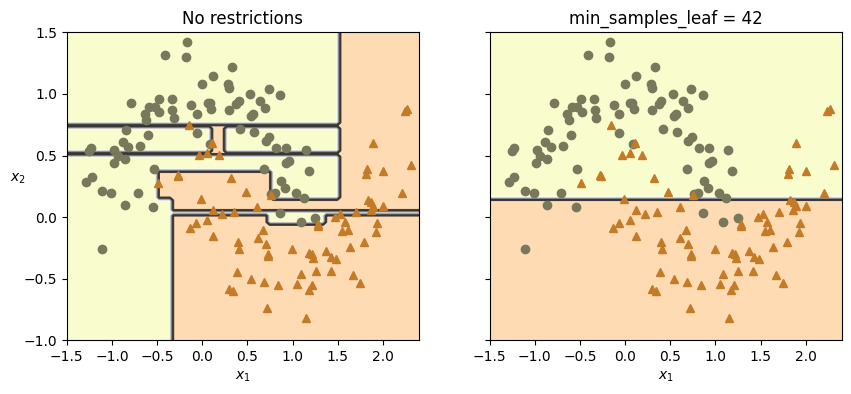

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

In [10]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_clf1,
    out_file='make_moons_tree.dot',
    feature_names=['petal length (cm)','petal width (cm)'],
    #class_names=make_moons.target_names,
    rounded=True,
    filled=True
)

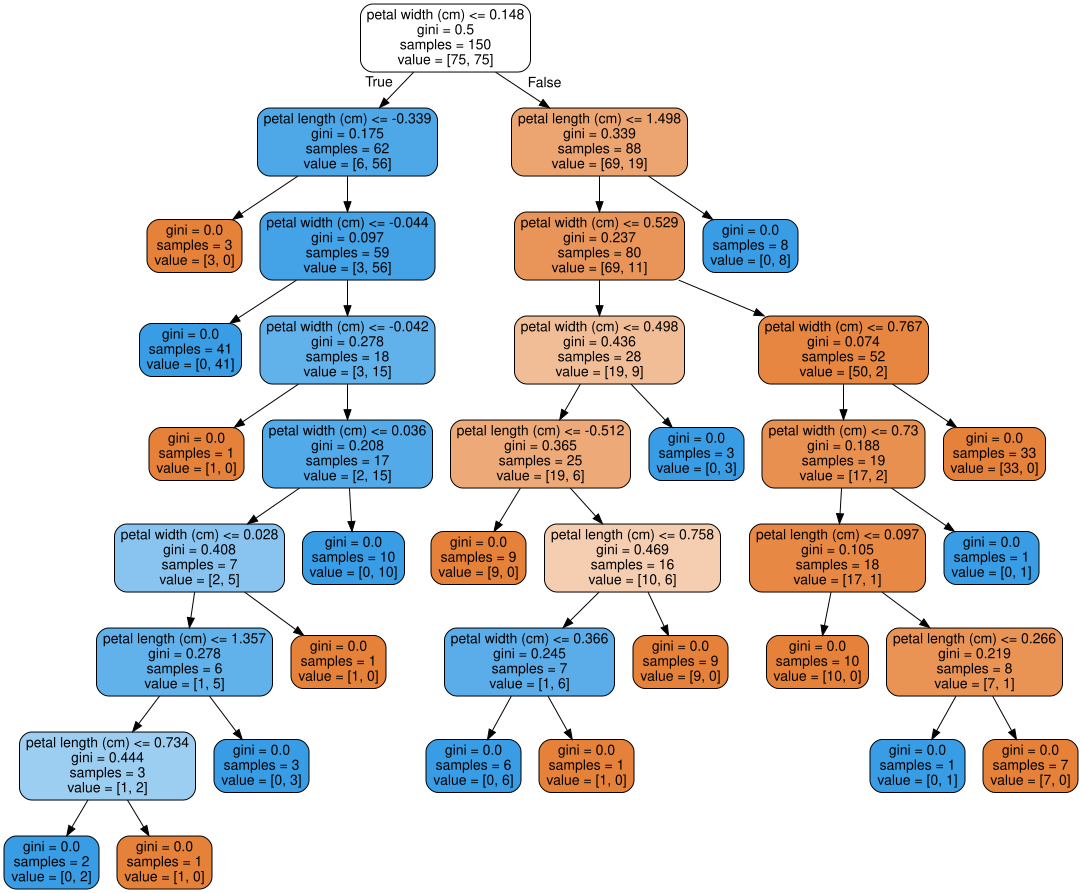

In [11]:
import graphviz
graphviz.Source.from_file('make_moons_tree.dot')

In [12]:
X_moons_test,y_moons_test=make_moons(n_samples=1000,noise=0.2,random_state=42)

print(tree_clf1.score(X_moons_test,y_moons_test) ,
tree_clf2.score(X_moons_test,y_moons_test))

0.901 0.816
